In [1]:
import env

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ds.cladder import load_cladder_v1_5, CLadderLoaderConfig, CLadderSample, CLadderDataset
from typing import Callable, Tuple

dsConfig = CLadderLoaderConfig(rung_filter=None, query_types=None, skip_unparseable=True)

org_ds = load_cladder_v1_5(dsConfig)

train, vald = CLadderDataset.from_samples_split(
    samples=org_ds,
    val_size=0.2,
    stratify=True
)


Processing 10112 rows...
Loaded 8532 graphs, skipped 1580 unparseable rows.


In [2]:
# Summary Stats
from typing import Literal

RUNG_LABELS = {0: "Associational", 1: "Interventional", 2: "Counterfactual"}
RUNG_ORDER  = [RUNG_LABELS[k] for k in sorted(RUNG_LABELS)]

def split_rung_table(
    train_samples: list[CLadderSample],
    vald_samples:  list[CLadderSample],
) -> pd.DataFrame:
    """
    Cross-tabulate train/validation split by rung.
    Each cell shows  N (row%)  ;  i.e. percentage of that split's total.
    Column totals show N (grand%).
    """
    rows = [
        {"split": "Train",      "rung": RUNG_LABELS[s.rung]} for s in train_samples
    ] + [
        {"split": "Validation", "rung": RUNG_LABELS[s.rung]} for s in vald_samples
    ]

    df = pd.DataFrame(rows)
    df["rung"]  = pd.Categorical(df["rung"],  categories=RUNG_ORDER, ordered=True)
    df["split"] = pd.Categorical(df["split"], categories=["Train", "Validation"], ordered=True)

    counts = (
        df.groupby(["split", "rung"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(RUNG_ORDER, axis=1, fill_value=0)
    )

    grand_total = len(rows)

    def fmt_row(row_series: pd.Series) -> list[str]:
        row_total = row_series.sum()
        return [f"{n} ({n / row_total * 100:.1f}%)" for n in row_series]

    def fmt_col_totals(col_series: pd.Series) -> list[str]:
        return [f"{n} ({n / grand_total * 100:.1f}%)" for n in col_series]

    out = pd.DataFrame(
        [fmt_row(counts.loc[split]) for split in counts.index],
        index=counts.index,
        columns=counts.columns,
    )

    # Row totals
    row_totals = counts.sum(axis=1)
    out["Total"] = [
        f"{n} ({n / grand_total * 100:.1f}%)" for n in row_totals
    ]

    # Column totals row
    col_totals = counts.sum(axis=0)
    out.loc["Total"] = fmt_col_totals(col_totals) + [
        f"{grand_total} (100.0%)"
    ]

    out.index.name   = "split"
    out.columns.name = "rung"
    return out




In [3]:
from pathlib import Path
p = Path("./graphs_and_tables/")
p.mkdir(parents=True, exist_ok=True)

table = split_rung_table(train.samples, vald.samples)
table.to_csv(p / "train_test_split.csv")
print(table)


rung       Associational Interventional Counterfactual          Total
split                                                                
Train       2528 (37.0%)   1264 (18.5%)   3033 (44.4%)   6825 (80.0%)
Validation   632 (37.0%)    316 (18.5%)    759 (44.5%)   1707 (20.0%)
Total       3160 (37.0%)   1580 (18.5%)   3792 (44.4%)  8532 (100.0%)


In [4]:
import numpy as np
from collections import Counter

def _extract_graph_metrics(samples: list[CLadderSample]) -> pd.DataFrame:
    """
    Deduplicate by graph_id, then extract per-graph structural metrics.

    Assumes CLadderSample.data is a PyTorch Geometric Data object, so:
      - nodes = len(node_names)          (always available)
      - edges = data.edge_index.shape[1] (directed edges, no self-loops assumed)
    """
    seen: dict[int, CLadderSample] = {}
    for s in samples:
        if s.graph_id not in seen:
            seen[s.graph_id] = s

    records = []
    for s in seen.values():
        n = len(s.node_names)
        e = int(s.data.edge_index.shape[1])
        records.append({
            "graph_id":      s.graph_id,
            "nodes":         n,
            "edges":         e,
            # Average number of edges leaving/entering each node
            "edges_per_node": round(e / n, 4) if n else 0.0,
            # Directed graph density: E / (N * (N-1)), max possible = 1.0
            "density":        round(e / (n * (n - 1)), 4) if n > 1 else 0.0,
        })

    return pd.DataFrame(records)


def _describe(series: pd.Series) -> dict:
    counts   = Counter(series)
    all_modes = [v for v, c in counts.items() if c == counts.most_common(1)[0][1]]
    return {
        "mean": round(float(series.mean()), 3),
        # Show all tied modes as a compact string, e.g. "3" or "3 / 4"
        "mode": " / ".join(str(m) for m in sorted(all_modes)),
        "min":  series.min(),
        "max":  series.max(),
    }


# ── main function ─────────────────────────────────────────────────────────────

def graph_structure_stats(
    samples: list[CLadderSample],
    label: str | None = None,
) -> pd.DataFrame:
    """
    Descriptive statistics over unique graphs present in `samples`.

    Parameters
    ----------
    samples : list[CLadderSample]
        Can be the full dataset, train.samples, or vald.samples.
    label : str, optional
        If provided, prepended as an outer index level (useful when
        concatenating train vs. validation tables).

    Returns
    -------
    pd.DataFrame  with metrics as rows, stats (mean/mode/min/max) as columns.

    Metrics
    -------
    Node Count      — number of nodes in the graph
    Edge Count      — number of directed edges (from edge_index)
    Edges / Node    — mean connectivity per node  (flow rate proxy)
    Graph Density   — E / N(N-1) for a directed graph  (0 = sparse, 1 = full)

    Notes
    -----
    Deduplication is done by graph_id, so repeated samples drawn from the
    same graph (across rungs/stories) are only counted once.
    """
    metrics = _extract_graph_metrics(samples)

    col_map = {
        "Node Count":   "nodes",
        "Edge Count":   "edges",
        "Edges / Node": "edges_per_node",
        "Graph Density":"density",
    }

    table = pd.DataFrame(
        {metric: _describe(metrics[col]) for metric, col in col_map.items()}
    ).T

    table.index.name   = "Metric"
    table.columns.name = "Statistic"

    n_unique = len(metrics)
    n_total  = len(samples)
    print(f"  → {n_unique} unique graph(s) across {n_total} sample(s)")

    if label:
        table.index = pd.MultiIndex.from_product([[label], table.index])

    return table





In [5]:
combined = pd.concat([
    graph_structure_stats(train.samples, label="Train"),
    graph_structure_stats(vald.samples,  label="Validation"),
])
print(combined)
combined.to_csv(p / "graph_stats.csv")

  → 10 unique graph(s) across 6825 sample(s)
  → 10 unique graph(s) across 1707 sample(s)
Statistic                  mean    mode     min   max
           Metric                                    
Train      Node Count       3.5   3 / 4       3     4
           Edge Count       3.3       4       2     5
           Edges / Node   0.925     1.0  0.6667  1.25
           Graph Density  0.375  0.3333  0.3333   0.5
Validation Node Count       3.5   3 / 4       3     4
           Edge Count       3.3       4       2     5
           Edges / Node   0.925     1.0  0.6667  1.25
           Graph Density  0.375  0.3333  0.3333   0.5


<ArrowStringArray>
['0_cadgn_mmd-0', '0_cadgn_mmd-1',  '1_adgn_mmd-0',  '1_adgn_mmd-1',
   '2_gcn_mmd-0',   '2_gcn_mmd-1',   '3_gat_mmd-0',   '3_gat_mmd-1',
   '4_dec_mmd-0',   '4_dec_mmd-1']
Length: 10, dtype: str
0 {'base': '0_cadgn', 'mmd': 0, 'epoch': np.int64(59), 'loss': np.float64(0.1293236005848104), 'color': (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), 'linestyle': '-', 'label': '0_cadgn (MMD=0)'}
1 {'base': '0_cadgn', 'mmd': 1, 'epoch': np.int64(59), 'loss': np.float64(0.1382921782135963), 'color': (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), 'linestyle': '--', 'label': '0_cadgn (MMD=1)'}
2 {'base': '1_adgn', 'mmd': 1, 'epoch': np.int64(59), 'loss': np.float64(0.131431135054339), 'color': (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), 'linestyle': '--', 'label': '1_adgn (MMD=1)'}
3 {'base': '2_gcn', 'mmd': 0, 'epoch': np.int64(59), 'loss': np.float64(0.5301702580262314), 'color': (0.3333333333333333, 0.6588235294117647, 0.40784

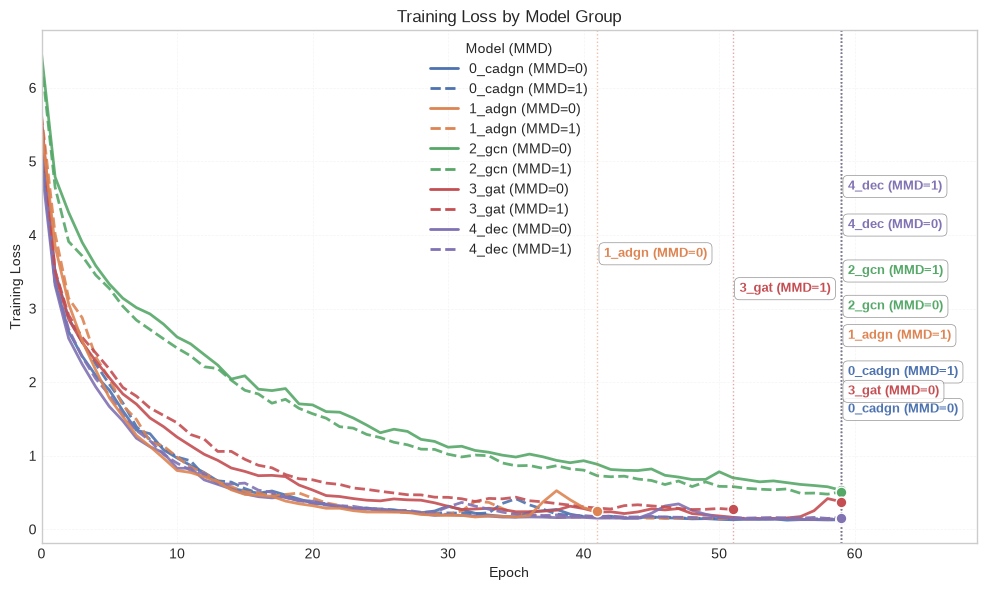

In [6]:
# Get Training Histories for Stage 1 and graph them...
import seaborn as sns
import matplotlib.pyplot as plt
import random
plt.style.use("seaborn-v0_8-whitegrid")

s1_trn_hist_path = Path("./ablate_results/stage1_history")
mmd_vals = [0.0, 1.0]
ablations = ["cadgn", "adgn", "gcn", "gat", "dec"]

fs = {}
for ai, abl in enumerate(ablations):
    for mi, mmd_val in enumerate(mmd_vals):
        mmd_str = str(int(mmd_val))
        filename = f"{ai}_{abl}_stage1_history_mmd-{mmd_str}.csv"
        f = pd.read_csv(
            s1_trn_hist_path / filename,
            index_col=0
        )
        key = f"{ai}_{abl}_mmd-{mmd_str}"
        fs[key] = f

s1_histories = pd.concat(fs, keys=list(fs.keys()))

overall_loss_per_model = {name: group['loss'] for name, group in s1_histories.groupby(level=0)}

overall_loss_df = pd.DataFrame(overall_loss_per_model)
df_long = overall_loss_df.reset_index().melt(
    id_vars="epoch",
    var_name="model",
    value_name="loss"
)
df_long['model'] = df_long['model'].astype(str)
df_long['epoch'] = df_long['epoch'].astype(int)
df_long['loss'] = pd.to_numeric(df_long['loss'], errors='coerce')
df_long = df_long.dropna()

# Extract base model name (e.g., "0_cadgn_mmd-0" -> "0_cadgn")
df_long['base_model'] = df_long['model'].str.replace(r'_mmd-\d+$', '', regex=True)
# Extract MMD value (0 or 1)
df_long['mmd_val'] = df_long['model'].str.extract(r'_mmd-(\d+)')[0].astype(int)



#print(df_long.dtypes)
print(df_long['model'].unique()[:10])

plt.figure(figsize=(10, 6))
# Create a color map based on unique base models
unique_bases = df_long['base_model'].unique()
#print(unique_bases)
palette = sns.color_palette("deep", len(unique_bases))
color_map = {base: color for base, color in zip(unique_bases, palette)}

# Collect all final data points for labeling

final_data = []
for base in unique_bases:
    # Filter data for this base model
    group_df = df_long[df_long['base_model'] == base]

    # Get the color for this base model
    color = color_map[base]

    for mmd_val in [0, 1]:
        mmd_df = group_df[group_df['mmd_val'] == mmd_val]
        if not mmd_df.empty:
            # Get final point data
            final_epoch = mmd_df['epoch'].max()
            final_loss = mmd_df.loc[mmd_df['epoch'] == final_epoch, 'loss'].values[0]

            # Store for label placement
            final_data.append({
                'base': base,
                'mmd': mmd_val,
                'epoch': final_epoch,
                'loss': final_loss,
                'color': color,
                'linestyle': '-' if mmd_val == 0 else '--',
                'label': f'{base} (MMD={mmd_val})'
            })

# Sort by epoch first
final_data.sort(key=lambda x: x['epoch'], reverse=True)
used_y_positions = []

# Iterate through the collected data to draw everything
for item in final_data:
    # Plot the line (using the original df for the full series)
    base = item['base']
    mmd_val = item['mmd']
    color = item['color']
    linestyle = item['linestyle']

    # Find the series data again to plot the full line
    group_df = df_long[df_long['base_model'] == base]
    mmd_df = group_df[group_df['mmd_val'] == mmd_val]

    plt.plot(
        mmd_df['epoch'],
        mmd_df['loss'],
        color=color,
        linestyle=linestyle,
        linewidth=2,
        alpha=0.9
    )

    # Draw vertical line to the final point
    plt.axvline(
        x=item['epoch'],
        color=color,
        linestyle=':',
        alpha=0.5,
        linewidth=1,
        clip_on=False  # Prevents line from being clipped by plot area
    )

    # Add marker
    plt.scatter(
        item['epoch'],
        item['loss'],
        color=color,
        s=60,
        zorder=5,
        edgecolors='white',
        linewidth=1
    )

# Place Labels non-overlapping
used_y_positions = []

for i, item in enumerate(final_data):
    print(i, item)
    x_pos = item['epoch'] + 0.5  # Offset to the right
    y_base = item['loss'] + 1.5

    # Find a y-position that doesn't overlap
    y_final = y_base
    while any(abs(y_final - y_used) < 0.15 for y_used in used_y_positions):
        y_final += 0.5  # Shift up

    used_y_positions.append(y_final)

    # Add text label
    plt.text(
        x_pos,
        y_final,
        item['label'],
        fontsize=9,
        color=item['color'],
        va='center',
        ha='left',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='gray', linewidth=0.5)
    )


# Custom Legend

from matplotlib.lines import Line2D
legend_elements = [
    (Line2D([0], [0], color=color_map[base], linestyle='-', linewidth=2, label=f'{base} (MMD=0)'),
    Line2D([0], [0], color=color_map[base], linestyle='--', linewidth=2, label=f'{base} (MMD=1)'))
    for base in unique_bases
]

legend_elements = [item for pair in legend_elements for item in pair]


# Add the legend manually
plt.legend(handles=legend_elements, title='Model (MMD)', loc='best')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss by Model Group')
plt.grid(True, linestyle='--', alpha=0.2)
max_epoch = df_long['epoch'].max()
plt.xlim(0, max_epoch + 10)  # Add padding for text

plt.tight_layout()
plt.show()


In [7]:
## Assessing the Performance of Stage 1 Modules: Graph Reconstruction
import json
p_abl_samples_s1 = Path("./ablate_results/samples/stage1")
p_abl_samples_s1.mkdir(parents=True, exist_ok=True)

files = {}
neles = {}
for ai, abl in enumerate(ablations):
    for mi, mmd_val in enumerate(mmd_vals):
        mmd_str = str(int(mmd_val))
        filename = f"{ai}_{abl}_all_mmd-{mmd_str}_s1-graph-preds.json"
        with open(p_abl_samples_s1/filename, 'r') as f:
            content = json.load(f)
        if type(content) == list:
            files[(abl, mmd_val)] = content[0]
            neles[(abl, mmd_val)] = len(content)
        else:
            files[(abl, mmd_val)] = content
            neles[(abl, mmd_val)] = 0

print(neles)
print(files[("cadgn", 1.0)]['sample_id'])


FileNotFoundError: [Errno 2] No such file or directory: 'ablate_results/samples/stage1/0_cadgn_all_mmd-0_s1-graph-preds.json'

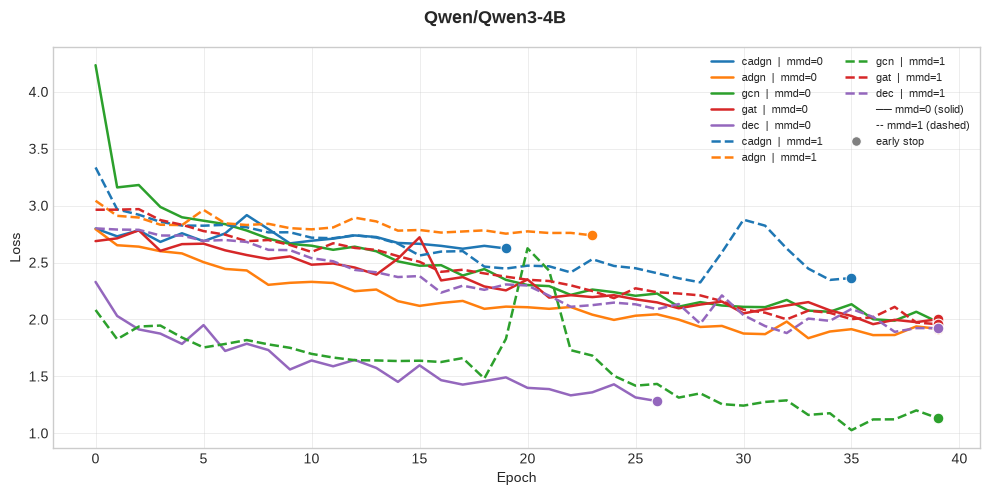

Saved for Qwen__Qwen3-4B!


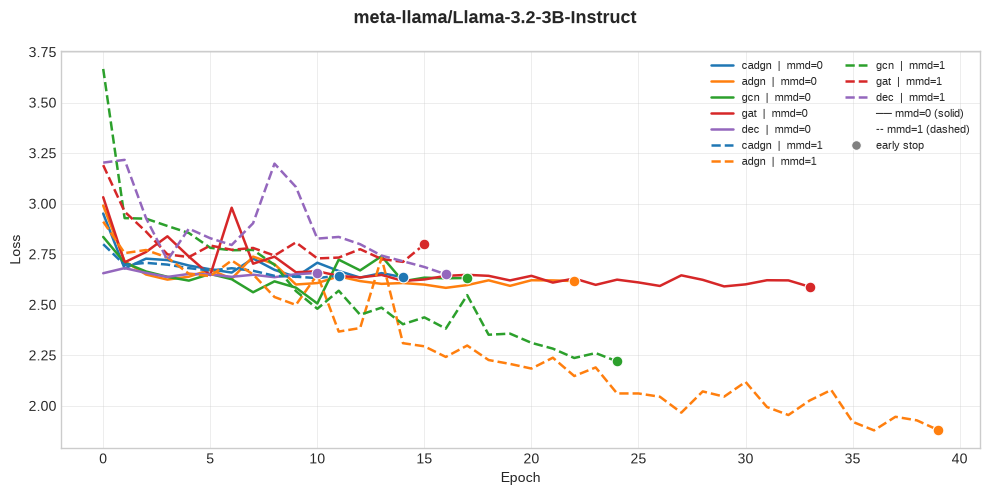

Saved for meta-llama__Llama-3.2-3B-Instruct!


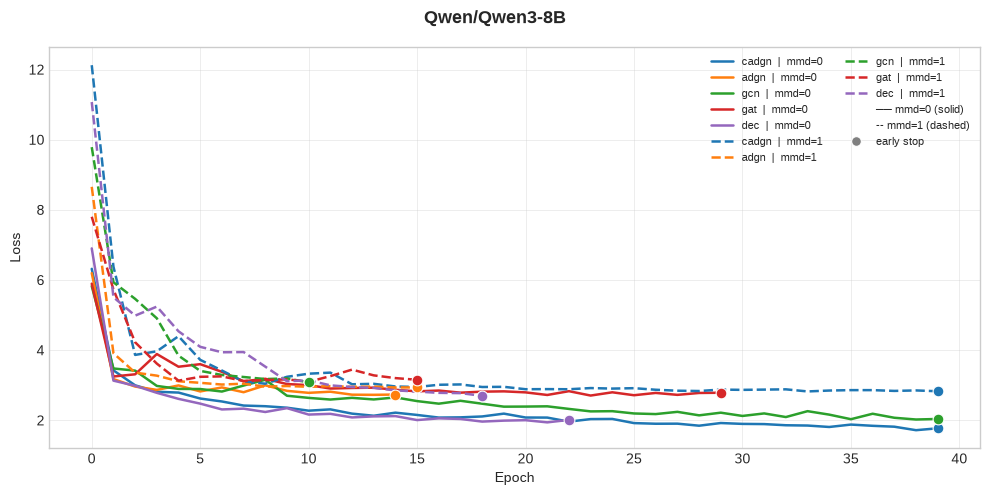

Saved for Qwen__Qwen3-8B!


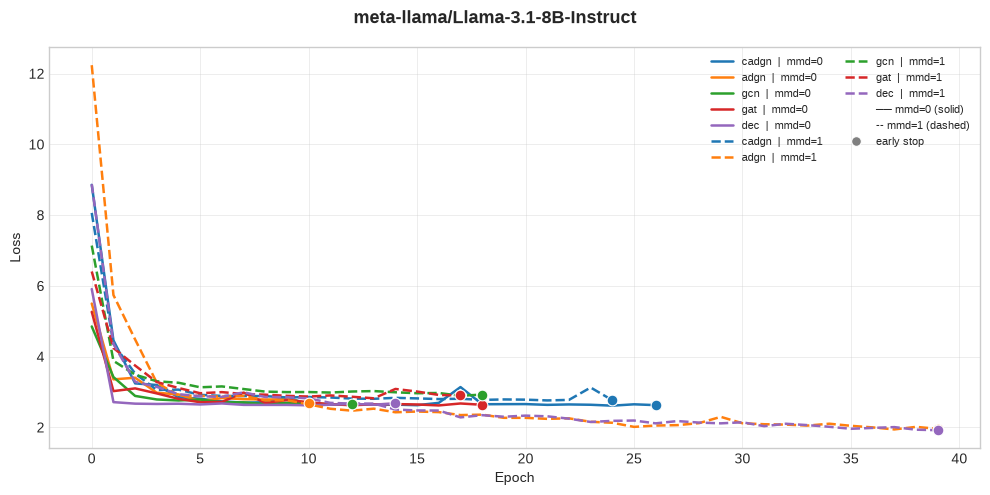

Saved for meta-llama__Llama-3.1-8B-Instruct!


In [9]:
## Stage 2 Training History Plots
from itertools import product
from matplotlib.lines import Line2D

s2_trn_hist_path = Path("./ablate_results/history")
do_models = [
    "Qwen/Qwen3-4B",
    "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.1-8B-Instruct",
]
abl_palette = dict(zip(ablations, sns.color_palette("tab10", n_colors=len(ablations))))
MMD_STYLE = {0: "-", 1: "--"}   # solid vs dashed


s2_hist_files = {}
for li, llm in enumerate(do_models):
    safe_name = llm.replace("/", "__")
    llm_hist_files = {}
    for mmd_val, abl in product([0,1], ablations):
        # `adgn_Qwen__Qwen3-8B_mmd-0_history.csv`
        pth = s2_trn_hist_path / f"{abl}_{safe_name}_mmd-{mmd_val}_history.csv"
        li_mi_ai_df = pd.read_csv(pth, index_col="epoch")
        llm_hist_files[(mmd_val, abl)] = li_mi_ai_df
    s2_hist_files[llm] = llm_hist_files
    # EOL
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(llm, fontsize=13, fontweight="bold")

    for mmd_val, abl in product([0,1], ablations):
        df = llm_hist_files[(mmd_val, abl)]
        color = abl_palette[abl]
        series = df["loss"].dropna()
        ax.plot(
            series.index,
            series.values,
            color=color,
            linestyle=MMD_STYLE[mmd_val],
            linewidth=1.8,
            label=f"{abl}  |  mmd={mmd_val}",
        )

        # add point at end of line.
        stop_epoch = series.index[-1]
        stop_loss = series.iloc[-1]
        ax.scatter(
            stop_epoch,
            stop_loss,
            color=color,
            edgecolors="white",
            linewidths=0.8,
            s=60,
            zorder=5
        )

    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel("Loss",  fontsize=10)

    # split legend: one section per MMD value for readability
    handles, labels = ax.get_legend_handles_labels()

    legend_extras = [
        Line2D([0], [0], color="none", label="── mmd=0 (solid)"),
        Line2D([0], [0], color="none", label="-- mmd=1 (dashed)"),
        # Explain early stopping points
        Line2D(
            [0], [0],
            marker="o", color="grey",
            markerfacecolor="grey", markeredgecolor="white",
            markeredgewidth=0.8, markersize=7,
            linestyle="none",
            label="early stop",
        ),
    ]
    ax.legend(
        handles=handles + legend_extras,
        labels=labels + [h.get_label() for h in legend_extras],
        fontsize=8,
        ncol=2,                  # ablations side-by-side for compactness
        loc="upper right",
        framealpha=0.7,
    )

    plt.tight_layout()
    save_path = s2_trn_hist_path / f"s2_{safe_name}_training_history.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved for {safe_name}!")


